# Proximity Analysis

Proximity analysis answers the question: *what is nearby?* This is a fundamental operation in geospatial analysis, used for applications ranging from finding the closest hospital to identifying all buildings within walking distance of a transit station.

**Topics covered in this module:**
- Nearest neighbor analysis using GeoPandas `.sjoin_nearest()`
- K-Nearest Neighbor (KNN) search using scipy's KD-Tree
- Radius-based queries: finding all features within a specified distance

## Learning Objectives

At the end of this module, you should be able to:
- Find the nearest feature using GeoPandas `.sjoin_nearest()` with distance calculation
- Explain what a spatial index (KD-Tree) is and why it makes nearest neighbor searches efficient
- Perform K-Nearest Neighbor (KNN) searches using `scipy.spatial.KDTree`
- Find all features within a given radius using `query_ball_tree()`
- Visualize proximity analysis results on interactive and static maps

In [1]:
# Turn off unwanted warnings
import warnings
warnings.filterwarnings("ignore")

## Nearest neighbor analysis

Neighbourhood is one of the fundamental concepts in geographic data analysis and modelling. Being able to understand how close geographic objects are to each other, or which features are neighboring a specific location is fundamental to various spatial analysis techniques, such as spatial autocorrelation or interpolation. Many of these techniques rely on the idea that proximity in geographic space indicates similarity in attribute space. 

For example, it is typical that a neighborhood with high population density is next to another neighborhood that also has high concentration of residents (i.e. population density tends to cluster). One of the most famous notions related to this is the **First law of geography** which states that "everything is related to everything else, but near things are more related than distant things". Thus, being able to understand how close geographic features are, or which objects are the closest ones to a specific location is an important task in GIS.

The Figure below illustrates two common ways to find nearest neighbors to specific locations. In these examples, we have two Point datasets visualized with blue circles and red rectangles. In the first example (top row), the idea is to find the closest geometry (rectangles) for all the points in the area. Here, the nearest neighbor is determined based on distance between the points and rectangles, and the nearest neighbors are visualized with a line from every point to the closest rectangle (on the right).

The bottom row shows an example in which we aim to find the closest point for each rectangle, but we also apply a maximum search distance that limits the search area. Only those points that are within the search area are considered, while the points outside of this area are simply ignored. As a result, the point closest to a given rectangle is visualized with a connected line (on the right).

In these examples, the geographic objects are simple point like features, but similar approach can be used with any geographic features, e.g., by finding the closest LineString or Polygon to a given Point, or by finding the closest Polygon to another Polygon. In these cases, the calculations are a bit more complicated, but the basic idea is the same.

With large datasets, we might want to limit the search area up to a specific maximum distance. This can be due to practical reasons as it can significantly speed up the computation time, or because we have specific reasoning that makes it sensible to limit the search area. For example, if we would aim to understand how accessible public transportation is to citizens living in a city, it would make sense to limit the search area e.g. up to 2 km from the homes of people, because people are not willing to walk for very long distances to reach a bus station. It's important to notice that the distances in the calculations are commonly based on the Euclidean distance, i.e. we calculate the distances based on coordinates on a Cartesian plain, meaning that the distances do not consider changes in height.

<img src="img/nearest-neighbor.png" width="600">

_The idea of finding a nearest neighbor based on geographic distance._

## Nearest neighbor analysis in Python

In Python, there are various libraries that can be used to find nearest neighbors for a given set of geometries, including `geopandas`, `shapely`, `scipy`, `scikit-learn`, and `pysal` among others. 

Here, we first introduce how `geopandas` can be used to find nearest neighbors for Point geometries in a GeoDataFrame based on Points in another GeoDataFrame. Then we show how to find K-Nearest Neighbors and perform radius queries using scipy, and finally we show how to use `scipy` library to find K-Nearest Neighbors (KNN) with Point data.

In the following, we go through a practical example: Where is the closest metro station to the GSA owned buildings in Washington DC? Our aim is to search for each building the closest metro station. In geopandas, we can find nearest neighbors for all geometries in a given GeoDataFrame using the `.sjoin_nearest()` method. 

Let's start by reading two datasets representing buildings and metro stations. Note that the input data are in ESRI Shapefile, in compressed (zip) form. You do NOT need to uncompress the files when reading them using geopandas.read_file().

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

stations = gpd.read_file("data/Metro_Stations_Regional.zip")
# Only keep the columns we need
stations = stations[['NAME','ADDRESS','LINE','GIS_ID', "geometry"]]

print("Number of stations:", len(stations))
stations.head(5)

Number of stations: 98


,NAME,ADDRESS,LINE,GIS_ID,geometry
0,Branch Ave,"4704 OLD SOPER ROAD, SUITLAND, MD",green,MetroStnFullPt_35,POINT (-8561745.283 4696843.014)
1,Braddock Road,"700 N. WEST ST., ALEXANDRIA, VA","blue, yellow",MetroStnFullPt_36,POINT (-8577575.293 4695085.215)
2,King St-Old Town,"1900 KING STREET, ALEXANDRIA, VA","blue, yellow",MetroStnFullPt_37,POINT (-8578370.519 4694005.549)
3,Eisenhower Ave,"2400 EISENHOWER AVENUE, ALEXANDRIA, VA",yellow,MetroStnFullPt_38,POINT (-8579490.747 4693125.524)
4,Huntington,"2701 HUNTINGTON AVENUE, ALEXANDRIA, VA",yellow,MetroStnFullPt_39,POINT (-8579972.917 4692195.740)


In [3]:
buildings = gpd.read_file("data/GSA_Federal_Locations.zip")
buildings = buildings[ ['REAL_PROPE', 'STREET_ADD','LATITUDE','LONGITUDE','GIS_ID','geometry'] ]

print("Number of buildings:", len(buildings))
buildings.head(5)

Number of buildings: 287


,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797)
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170)
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034)
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025)
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170)


In [4]:
stations.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
buildings.crs

<Projected CRS: EPSG:26985>
Name: NAD83 / Maryland
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Maryland - counties of Allegany; Anne Arundel; Baltimore; Calvert; Caroline; Carroll; Cecil; Charles; Dorchester; Frederick; Garrett; Harford; Howard; Kent; Montgomery; Prince Georges; Queen Annes; Somerset; St Marys; Talbot; Washington; Wicomico; Worcester.
- bounds: (-79.49, 37.97, -74.97, 39.73)
Coordinate Operation:
- name: SPCS83 Maryland zone (meters)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

As we can see, there are 98 metro stations, and 287 GSA owned or leased buildings. Both GeoDataFrames contain Point geometries, but use different map projections!

We need to first reproject `stations` to the same projection of `buildings` (EPSG:26985), before joining them for nearest neighbor analysis.


In [6]:
stations = stations.to_crs(buildings.crs)
stations.crs

<Projected CRS: EPSG:26985>
Name: NAD83 / Maryland
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Maryland - counties of Allegany; Anne Arundel; Baltimore; Calvert; Caroline; Carroll; Cecil; Charles; Dorchester; Frederick; Garrett; Harford; Howard; Kent; Montgomery; Prince Georges; Queen Annes; Somerset; St Marys; Talbot; Washington; Wicomico; Worcester.
- bounds: (-79.49, 37.97, -74.97, 39.73)
Coordinate Operation:
- name: SPCS83 Maryland zone (meters)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

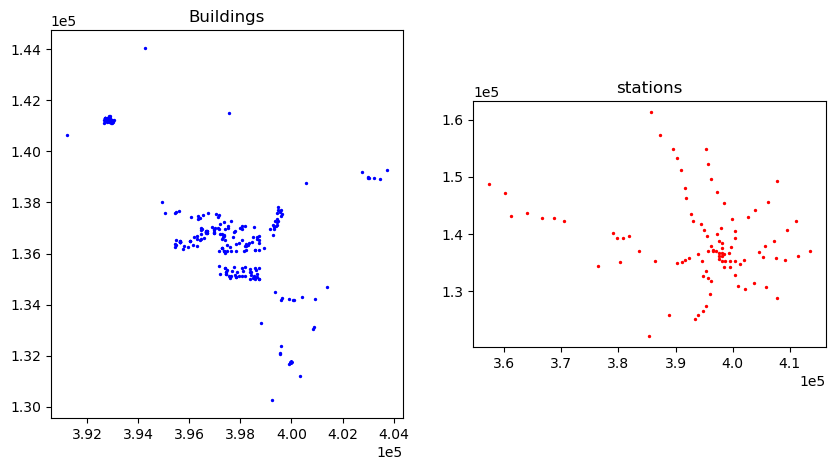

In [7]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))

# Plot buildings
buildings.plot(ax=ax1,markersize=2,alpha=1,color="b")
ax1.set_title("Buildings")

# Plot stations
stations.plot(ax=ax2,markersize=2,alpha=1,color="r")
ax2.set_title("stations")

# show tickmark labels in scientific notation
ax1.ticklabel_format(style='sci', scilimits=(0,0))
ax2.ticklabel_format(style='sci', scilimits=(0,0))

Let's plot them on an interactive map:

In [8]:
m = buildings.explore(color='red',marker_kwds=dict(radius=5),tiles="CartoDB Positron", max_zoom=16)
stations.explore(m=m, color='blue',marker_kwds=dict(radius=5))

Finding the nearest geometries between two GeoDataFrames can be done using the `.sjoin_nearest()` method in geopandas. This method is designed to merge data between GeoDataFrames in a similar manner as with `.sjoin()` method. However, the method searches for the closest geometries instead of relying on spatial predicates. 

The sjoin_nearest() can be used for different geometry types, so the input geometries do not necessarily need to be Point objects as in our example. Under the hood, the method uses a **spatial index** called **STRTree** which is an efficient implementation of the **R-tree** dynamic index structure for spatial searching. The STRTree is implemented in the shapely library and the technique makes the nearest neighbor queries very efficient. 

For the method to work properly, it is recommended to ensure that the both GeoDataFrames have the same CRS, and preferably a **projected (metric) CRS** because it ensures that the reported distances are meaningful (in meters) and correct.

After confirming the GeoDataFrames are in the same CRS and the coordinates are represented in meters, we can use `buildings.sjoin_nearest()` to find the closest station for each building. Because we are interested in finding the closest station for each building, the _buildings_ GeoDataFrame is the left hand side of the command. As inputs, we pass the _stations_ GeoDataFrame and a name for a column to store the distance between a given building and the closest station (this is optional):

In [9]:
closest = buildings.sjoin_nearest(stations, distance_col="distance")
closest

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID_left,geometry,index_right,NAME,ADDRESS,LINE,GIS_ID_right,distance
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,Anacostia,"1101 HOWARD ROAD SE, WASHINGTON, DC",green,MetroStnFullPt_40,1125.971923
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,55.397993
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,Foggy Bottom-GWU,"890 23RD STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_8,615.199611
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917
...,...,...,...,...,...,...,...,...,...,...,...,...
282,395 PATRIOTS PLAZA,395 E ST SW,38.883313,-77.017386,GSAPt_283,POINT (398491.717 135052.171),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,236.621412
283,2430 E ST NW SOUTH,2430 E ST NW,38.894294,-77.052687,GSAPt_284,POINT (395429.560 136272.300),59,Foggy Bottom-GWU,"890 23RD STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_8,742.481232
284,WORLD TRADE CENTER - DC,400 VIRGINIA AVE SW,38.884200,-77.018051,GSAPt_285,POINT (398434.038 135150.668),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,212.899322
285,ST E; 52; ICE PLANT,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_286,POINT (399969.731 131754.797),5,Anacostia,"1101 HOWARD ROAD SE, WASHINGTON, DC",green,MetroStnFullPt_40,1125.971923


We now have found the closest metro station for each building, including the station attributes that were merged into the results. The last column in the table shows the distance in meters between a given building and the closest station. The distance is only returned upon request by specifying `distance_col="distance"`. The column `index_right` provides information about the index number of the closest station in the `stations` GeoDataFrame.

#### Quiz

In the previous module, we used `sjoin()` with a spatial predicate like "within". In this module, we used `sjoin_nearest()`. What is the fundamental difference? Can `sjoin()` answer the question "which metro station is closest to this building"?

In [ ]:
# Use this cell to enter your solution.


We can also specify a `max_distance` parameter to limit the search within a maximum search distance, say, 500 m:

In [10]:
closest_limited = buildings.sjoin_nearest(stations, max_distance=500, distance_col="distance")
closest_limited

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID_left,geometry,index_right,NAME,ADDRESS,LINE,GIS_ID_right,distance
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,55.397993
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917
5,810 7TH STREET NW,810 7TH ST NW,38.900480,-77.022411,GSAPt_6,POINT (398056.195 136957.959),79,Gallery Pl-Chinatown,"625 9TH STREET NW, WASHINGTON, DC","red, green, yellow",MetroStnFullPt_28,242.148202
7,DOT HQ EAST BUILDING,1201 4TH ST SE,38.875833,-77.001098,GSAPt_8,POINT (399904.921 134221.713),28,Navy Yard-Ballpark,"1155 NEW JERSEY AVENUE SE, WASHINGTON, DC",green,MetroStnFullPt_80,354.428816
...,...,...,...,...,...,...,...,...,...,...,...,...
280,COLUMBIA PLAZA - 2401 E ST,2401 E ST NW,38.896590,-77.052111,GSAPt_281,POINT (395479.674 136527.190),59,Foggy Bottom-GWU,"890 23RD STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_8,484.356501
281,NATIONAL BUILDING MUSEUM,401 F ST NW,38.897790,-77.017521,GSAPt_282,POINT (398480.312 136659.255),76,Judiciary Square,"435 4TH STREET NW, WASHINGTON, DC",red,MetroStnFullPt_25,201.767028
282,395 PATRIOTS PLAZA,395 E ST SW,38.883313,-77.017386,GSAPt_283,POINT (398491.717 135052.171),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,236.621412
284,WORLD TRADE CENTER - DC,400 VIRGINIA AVE SW,38.884200,-77.018051,GSAPt_285,POINT (398434.038 135150.668),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,212.899322


One important aspect to notice from these results is that the number of rows has decreased. This happens because there were some buildings that did not have any stations within the 500 m search radius. Because the default join type in `sjoin_nearest` is **inner** join, all the records that did not have a station within 500 m were dropped. 

If you want to keep all the records in the results, to e.g. investigate which buildings do not have any stations within the search radius, you can add parameter **how="left"**, which will retain all buildings from the original GeoDataFrame.


#### Quiz

When we added `max_distance=500` to `sjoin_nearest()`, the result had fewer rows than the original buildings GeoDataFrame. Why? What join type would you use if you wanted to keep all buildings even when no station is within 500 m?

In [ ]:
# Use this cell to enter your solution.


In some cases, you might actually want to connect the nearest neighbors to each other with a straight line. To do this, we need to merge also the Point geometries from the other layer into the results, which can then be used to create a LineString connecting the points to each other. To merge the closest station geometries into our results, we can take advantage of the **index_right** column in our table and conduct an **attribute join** using the `.merge()` method.

Below, we perform an attribute join using `.merge()` and the **index_right** column in `closest` as a key on the left table while the index of the `stations` is used as the key on the right table. Notice that we only keep the **geometry** columns from `stations` because all the other attributes already existed.

In [11]:
closest = closest.merge(stations['geometry'], left_on="index_right", right_index=True)
closest.head()

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID_left,geometry_x,index_right,NAME,ADDRESS,LINE,GIS_ID_right,distance,geometry_y
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,Anacostia,"1101 HOWARD ROAD SE, WASHINGTON, DC",green,MetroStnFullPt_40,1125.971923,POINT (400401.290 132794.783)
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917,POINT (397082.035 137054.637)
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,55.397993,POINT (398622.773 135249.183)
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,Foggy Bottom-GWU,"890 23RD STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_8,615.199611,POINT (395638.299 136984.835)
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917,POINT (397082.035 137054.637)


As a result, we now have a new column, namely the **geometry_y**. Because there was a column called geometry in both GeoDataFrames, geopandas automatically renamed the columns into geometry_x and geometry_y respectively. 

The result `closest` is a pandas DataFrame, NOT a geopandas GeoDataFrame, since there is no **geometry** column any more. But no worries, we will use the **geometry_x** and **geometry_y** columns to create a new geometry column of LineStrings object.

In [12]:
from shapely.geometry import LineString

# Create LineString from geometry_x and geometry_y
closest["geometry"] = closest.apply(lambda row: LineString([row.geometry_x, row.geometry_y]), axis=1)

# Convert from pandas DataFrame to geopandas GeoDataFrame
closest = gpd.GeoDataFrame(closest, geometry="geometry")

# Set the crs to be the same of buildings and stations
closest = closest.set_crs(stations.crs)

closest.head(5)

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID_left,geometry_x,index_right,NAME,ADDRESS,LINE,GIS_ID_right,distance,geometry_y,geometry
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,Anacostia,"1101 HOWARD ROAD SE, WASHINGTON, DC",green,MetroStnFullPt_40,1125.971923,POINT (400401.290 132794.783),"LINESTRING (399969.731 131754.797, 400401.290 ..."
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917,POINT (397082.035 137054.637),"LINESTRING (396957.788 136793.170, 397082.035 ..."
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,Federal Center SW,"401 3RD STREET SW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_24,55.397993,POINT (398622.773 135249.183),"LINESTRING (398634.468 135195.034, 398622.773 ..."
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,Foggy Bottom-GWU,"890 23RD STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_8,615.199611,POINT (395638.299 136984.835),"LINESTRING (396027.044 136508.025, 395638.299 ..."
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,289.486917,POINT (397082.035 137054.637),"LINESTRING (396957.788 136793.170, 397082.035 ..."


Now we have created a new geometry column that contains the lines between buildings and the closest stations. 

Let's create a map to visualize the buildings, stations, and connecting lines between the buildings and the closest station: 

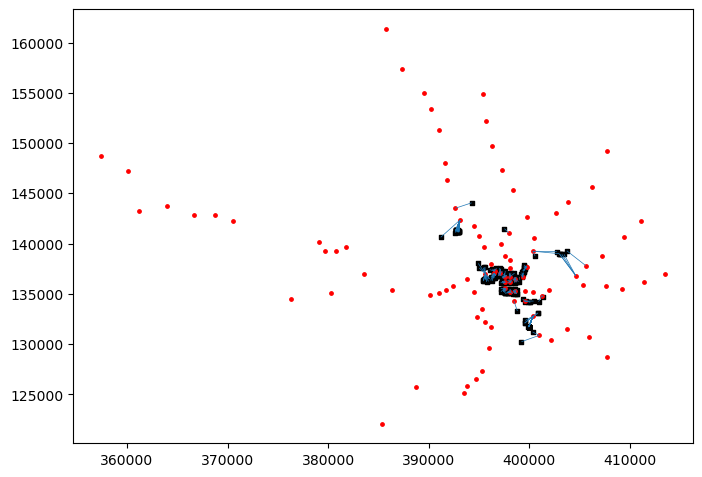

In [13]:
ax = closest.plot(lw=0.5, figsize=(8,8))
ax = buildings.plot(ax=ax, color="k", markersize=5, marker="s")
ax = stations.plot(ax=ax, color="r", markersize=6, marker="o")

As we can see, the nearest neighbor search have worked as planned, and each building has been correctly connected with a line to the closest station. The map reveals that there are multiple isolated stations that do not have any buildings connected to them. 

## K-Nearest Neighbor search

Thus far, we have only focused on finding the nearest neighbor to a given geometry. However, we might want to find not only the closest geometry, but a specific number of closest geometries to a given location (1st closest, 2nd closest, and so on). For example, we might be interested to find 3-5 closest public transport stations from your home, because these stations might provide alternative connections to different parts of the city. Doing these kind of queries is a common procedure and a prerequisite for many data analysis techniques, and the technique is commonly called `K-Nearest Neighbors search` (or KNN search).

Next, we will learn how to find *k* number of closest neighbors based on two GeoDataFrames. We will first aim to find the three nearest metro stations for each building, and then we will see how to make a `radius query` to find all neighbors within specific distance apart from a given location. 

K-Nearest Neighbor search techniques are typically built on top of `spatial indices` to make the queries more efficient. Previously, with `sjoin_nearest()`, we used an `R-tree` index structure to efficiently find the nearest neighbor for any kind of geometry. However, because the R-tree implementation in Python only supports finding the closest neighbor, we need to use another tree structure called `KD-Tree` (K-dimensional tree) that can provide information about K-nearest neighbors. KD-tree is similar to R-tree, but the data is ordered and sorted in a bit different manner.

In Python, we can conduct KNN search using the `scipy` library. Before we can do the actual query, we need to build the `KD-Tree` spatial index. In scipy, we can use `KDTree` to build the spatial index from the `scipy.spatial` submodule.

In the following, we use the `buildings` and `stations` GeoDataFrames to find three closest metro stations for each building. Let's start by reading the data and reproject the GeoDataFrames into the same CRS (EPSG:26985).

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

stations = gpd.read_file("data/Metro_Stations_Regional.zip").to_crs(epsg=26985)
stations = stations[['NAME','ADDRESS','LINE','GIS_ID', "geometry"]]

buildings = gpd.read_file("data/GSA_Federal_Locations.zip")
buildings = buildings[ ['REAL_PROPE', 'STREET_ADD','LATITUDE','LONGITUDE','GIS_ID','geometry'] ]


As a first step, we need to build a `KDTree` index structure based on the Point coordinates. The KDTree class expects the Point coordinates to be in **array** format, i.e. not as shapely **Point** objects in the **geometry** column. Luckily, it is easy to convert shapely geometries into numpy.array format by chaining a method `.get_coordinates()` with the .to_numpy() method as follows: 

In [15]:
building_coords = buildings.get_coordinates().to_numpy()
station_coords = stations.geometry.get_coordinates().to_numpy()
station_coords

array([[407687.35286422, 128744.86463161],
       [395338.59039152, 127376.85958007],
       [394717.62051806, 126538.31423041],
       [393843.03015011, 125855.07403556],
       [393466.18879536, 125132.77136355],
       [400401.28972418, 132794.78254094],
       [400346.48012334, 135199.10559057],
       [401258.04792357, 134826.32249864],
       [401987.29357007, 135430.99712585],
       [400351.88174399, 139243.95103515],
       [404618.88594173, 136817.70262292],
       [394539.20037161, 141710.84139844],
       [394967.17040488, 140766.7173582 ],
       [397176.95007935, 139996.89432827],
       [379054.42425251, 140147.75963447],
       [379718.08362722, 139258.35608903],
       [380772.68602702, 139224.51667086],
       [381782.78700834, 139649.23242656],
       [411109.06577698, 142218.44423816],
       [409433.00497292, 140631.21759673],
       [407229.84715057, 138755.70271029],
       [413483.587186  , 136984.16876531],
       [399737.55557558, 137685.00738218],
       [393

By running these commands, the `.get_coordinates()` method first returns a DataFrame with `x` and `y` coordinates as columns, and the `.to_numpy()` method then converts this data into a numpy **array** as we see above. The **station_coords** variable now contains an array of coordinate tuples (x and y coordinates) which we can pass to the **KDTree** class and create a KD-Tree index structure as follows: 

In [16]:
from scipy.spatial import KDTree

station_kdt = KDTree(station_coords)
station_kdt

Now we have initialized a `KDTree` index structure by populating it with station coordinates. By doing this, we can make very efficient queries to find out which of the stations is closest to specific buildings. To do this, we can use the `.query()` method which goes through all the input coordinates (i.e. buildings) and quickly calculates which of them is the closest, 2nd closest etc. The method returns the distances to the K-number of nearest neighbors as well as the index of the closest `station` to the given building. By passing an argument `k=3`, we can specify that we want to find three closest neighbors for each building: 

In [17]:
# Find the three nearest neighbors from station KD-Tree for each building
k_nearest_dist, k_nearest_ix = station_kdt.query(building_coords, k=3)

len(k_nearest_dist)

287

The `station_kdt.query()` call returns us two objects. The first variable `k_nearest_dist` represents an array of distances from each building to the three of the closest stations. The second variable `k_nearest_ix` represents the index values of the three nearest stations for each building:

In [18]:
# Distances to 3 nearest stations
k_nearest_dist

array([[1125.97192303, 1353.14268837, 2573.69216307],
       [ 289.48691683,  552.94030262,  610.56822662],
       [  55.3979933 ,  536.50858611,  914.69518724],
       [ 615.19961099,  701.73939952,  921.23293869],
       [ 289.48691683,  552.94030262,  610.56822662],
       [ 242.14820177,  547.05673486,  664.32071655],
       [ 515.08725392,  543.82501524,  582.9597588 ],
       [ 354.42881595, 1072.506662  , 1084.72936563],
       [ 198.99322502,  556.41845821,  653.0145935 ],
       [1125.97192303, 1353.14268837, 2573.69216307],
       [1199.10385253, 1623.16004502, 1980.43189955],
       [ 463.07867732,  551.41313712, 1036.07947941],
       [ 280.14821912, 1048.85725443, 1361.58216203],
       [1116.08983788, 1904.60561345, 2202.58017543],
       [ 319.87566621,  552.59675927,  795.00199254],
       [ 295.72289328,  418.45882301,  851.297215  ],
       [ 299.01132092,  486.29768163,  820.6426241 ],
       [ 137.58396285,  564.55687962,  644.38960194],
       [ 315.01677702,  476.

In [19]:
# Index values of the 3 nearest stations
k_nearest_ix

array([[ 5, 83, 28],
       [29, 65, 78],
       [75, 68, 71],
       [59, 65, 66],
       [29, 65, 78],
       [79, 78, 80],
       [66, 65, 25],
       [28,  6, 77],
       [90, 69, 78],
       [ 5, 83, 28],
       [33, 11, 12],
       [69, 68, 90],
       [22, 82, 80],
       [ 5, 83, 28],
       [29, 78, 66],
       [69, 68, 90],
       [68, 69, 75],
       [29, 78, 66],
       [65, 66, 29],
       [65, 66, 29],
       [ 5, 83, 28],
       [68, 75, 71],
       [75, 68, 77],
       [65, 66, 29],
       [69, 68, 90],
       [22, 82, 80],
       [33, 11, 12],
       [65, 66, 29],
       [33, 11, 88],
       [65, 66, 29],
       [22, 82, 76],
       [28, 77, 71],
       [78, 29, 79],
       [59, 25, 65],
       [22, 82, 76],
       [ 5, 28,  7],
       [ 5, 83, 28],
       [65, 66, 29],
       [90, 69, 78],
       [ 5, 83, 28],
       [82, 22, 76],
       [ 5, 83, 28],
       [59, 25, 65],
       [ 5, 83, 28],
       [22, 82, 80],
       [33, 11, 12],
       [82, 76, 22],
       [59, 6

Based on these arrays, we can see that the closest station to the first building is 1125 meters away, while the second and third closest metro stations are 1353 and 2573 meters away. By looking at the index values in the `k_nearest_ix` variable, we can see that the stations with indices 5, 83, and 28 are the three closest metro stations to the first building. 

Now we have successfully computed the K-nearest neighbors between the buildings and metro stations. Next, we will attach this information back to our GeoDataFrame so that it is easier to do further analyses. The data returned by `station_kdt.query()` come out as an array of lists, where each item (list) contains three values that show the distances between three nearest stations and the given building. To merge this data with the original GeoDataFrame containing the building data, we need to transpose our arrays. After the transpose, the data will be restructured in a way that there will be three arrays and each of these arrays contains the distances/station-ids for all the buildings in a single list. To transpose a numpy array, we can use the method `.T` which does the trick:

In [20]:
k_nearest_ix.T

array([[ 5, 29, 75, 59, 29, 79, 66, 28, 90,  5, 33, 69, 22,  5, 29, 69,
        68, 29, 65, 65,  5, 68, 75, 65, 69, 22, 33, 65, 33, 65, 22, 28,
        78, 59, 22,  5,  5, 65, 90,  5, 82,  5, 59,  5, 22, 33, 82, 59,
         5, 28,  5, 90, 75, 29, 70,  5, 65,  9, 22, 10, 29, 65, 59, 69,
         5,  5, 76, 65, 69, 59, 59, 33, 83, 65, 29,  5, 59, 75, 59,  5,
        59, 66, 29,  5, 75, 78, 33, 66, 68, 65,  5, 90,  5, 10, 22, 76,
        65, 33,  5, 65, 66, 75, 78, 78,  5, 10, 22, 82, 69,  5, 82, 82,
        78, 75, 65, 59, 69, 33,  5, 33, 70, 22, 71, 29,  5, 69, 65, 90,
        51, 75, 29, 79, 33,  5, 33, 33, 76, 33, 78,  5,  5, 33, 76, 33,
         5, 68, 59, 33,  5, 90, 69, 65,  5, 68,  5, 59, 33,  9, 70,  5,
        79, 69,  5, 28,  5, 33, 33,  7, 65, 68, 59, 76, 33,  5, 70, 59,
        75, 79, 28,  5,  5, 33, 78, 70, 28, 90,  5, 59, 76,  5, 76, 88,
        33, 68, 22, 59,  5,  5, 90,  5, 68, 29, 78, 59, 66, 70, 78, 68,
        65, 33, 79,  5, 76, 33, 59, 29, 76, 68, 65, 69, 69,  5, 

By following this approach, we can store the index and distance information as columns into our GeoDataFrame containing values for the 1-3 nearest stations. In the following, we first create a clean copy of the `buildings` GeoDataFrame into variable `k_nearest`, which we will then populate with three new columns for the station indices, and three columns for the distances to the 1-3 closest stations. To access the information for the closest station, we can call `.T[0]`, while the `.T[1]` and `.T[2]` returns the information for the second and third closest stations accordingly:

In [21]:
# Make a copy
k_nearest = buildings.copy()

# Add indices of nearest stations
k_nearest["1st_nearest_idx"] = k_nearest_ix.T[0]
k_nearest["2nd_nearest_idx"] = k_nearest_ix.T[1]
k_nearest["3rd_nearest_idx"] = k_nearest_ix.T[2]

# Add distances
k_nearest["1st_nearest_dist"] = k_nearest_dist.T[0]
k_nearest["2nd_nearest_dist"] = k_nearest_dist.T[1]
k_nearest["3rd_nearest_dist"] = k_nearest_dist.T[2]

In [22]:
k_nearest.head(5)

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,83,28,1125.971923,1353.142688,2573.692163
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,68,71,55.397993,536.508586,914.695187
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,65,66,615.199611,701.739400,921.232939
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227


Perfect! Now we have stored the information for each building about the indices and distances to the three of the closest stations around given buildings. To make this information easier to understand, we can make a nice map that shows the closest three stations for each building. To do this, we can follow a similar approach as we used earlier. Namely, we bring the geometry from the k-nearest stations and connect the building Points with the given station Points with a LineString. Then it is easy to visualize the closest stations for each building. 

In the following, we create three separate GeoDataFrames that correspond to the nearest, second nearest and third nearest stations from the buildings. We start by storing the `station_index` as a column which allows us to easily merge the data between **stations** and **k_nearest** (buildings) GeoDataFrames. For making the table join, we can use the pandas `.merge()` function in which we use the **1st_nearest_idx**,  **2nd_nearest_idx** and **3rd_nearest_idx** as the key on the left GeoDataFrame, while the station_index is the key on the right GeoDataFrame. We also pass the `suffixes=('', '_knearest)` argument to the `.merge()` method to specify that the column names on the left-side GeoDataFrame should stay as they are, while the column names on the right-side will get a suffix **_knearest** in case there are identical column names present in both GeoDataFrames (which we have as both frames contain the **geometry** column). 

Let's see how we can create these three GeoDataFrames and store them into **k_nearest_1**, **k_nearest_2** and **k_nearest_3** variables:

In [23]:
# Store the station index for making the table join
stations["station_index"] = stations.index

In [24]:
# Merge the geometries of the nearest stations to the GeoDataFrame
k_nearest_1 = k_nearest.merge(
    stations[["station_index", "geometry"]],
    left_on="1st_nearest_idx",
    right_on="station_index",
    suffixes=("", "_knearest"),
)
k_nearest_1.head(5)

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,station_index,geometry_knearest
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,83,28,1125.971923,1353.142688,2573.692163,5,POINT (400401.290 132794.783)
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227,29,POINT (397082.035 137054.637)
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,68,71,55.397993,536.508586,914.695187,75,POINT (398622.773 135249.183)
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,65,66,615.199611,701.739400,921.232939,59,POINT (395638.299 136984.835)
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227,29,POINT (397082.035 137054.637)


In [25]:
# Merge the geometries of the 2nd nearest stations to the GeoDataFrame
k_nearest_2 = k_nearest.merge(
    stations[["station_index", "geometry"]],
    left_on="2nd_nearest_idx",
    right_on="station_index",
    suffixes=("", "_knearest"),
)
k_nearest_2.head(5)

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,station_index,geometry_knearest
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,83,28,1125.971923,1353.142688,2573.692163,83,POINT (400996.794 130873.810)
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227,65,POINT (396469.527 137052.678)
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,68,71,55.397993,536.508586,914.695187,68,POINT (398098.702 135223.247)
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,65,66,615.199611,701.739400,921.232939,65,POINT (396469.527 137052.678)
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227,65,POINT (396469.527 137052.678)


In [26]:
# Merge the geometries of the 3rd nearest stations to the GeoDataFrame
k_nearest_3 = k_nearest.merge(
    stations[["station_index", "geometry"]],
    left_on="3rd_nearest_idx",
    right_on="station_index",
    suffixes=("", "_knearest"),
)
k_nearest_3.head(5)

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,station_index,geometry_knearest
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,83,28,1125.971923,1353.142688,2573.692163,28,POINT (399558.232 134295.380)
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227,78,POINT (397563.886 136719.417)
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,68,71,55.397993,536.508586,914.695187,71,POINT (398480.559 134293.380)
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,65,66,615.199611,701.739400,921.232939,66,POINT (396555.892 137262.340)
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227,78,POINT (397563.886 136719.417)


Now we have merged station geometries into the `geometry_knearest` column of the GeoDataFrames. By comparing the `station_index` column of **k_nearest_1**, **k_nearest_2** and **k_nearest_3**, we can see that the values change correctly following the **1st_**, **2nd_**, and **3rd_nearest_index** column accordingly. The geometries stored in the `geometry_knearest` also have different values in all of the GeoDataFrames. 

Now we can create LineString geometries connecting these Point objects to each other which allows us to create a nice map out of our nearest neighbors:

In [27]:
from shapely import LineString

# Generate LineStrings connecting the building point and K-nearest neighbor
k_nearest_1["geometry"] = k_nearest_1.apply(lambda row: LineString([row["geometry"], row["geometry_knearest"]]), axis=1 )
k_nearest_2["geometry"] = k_nearest_2.apply(lambda row: LineString([row["geometry"], row["geometry_knearest"]]), axis=1 )
k_nearest_3["geometry"] = k_nearest_3.apply(lambda row: LineString([row["geometry"], row["geometry_knearest"]]), axis=1 )
k_nearest_1.head(5)

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,station_index,geometry_knearest
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,"LINESTRING (399969.731 131754.797, 400401.290 ...",5,83,28,1125.971923,1353.142688,2573.692163,5,POINT (400401.290 132794.783)
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,"LINESTRING (396957.788 136793.170, 397082.035 ...",29,65,78,289.486917,552.940303,610.568227,29,POINT (397082.035 137054.637)
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,"LINESTRING (398634.468 135195.034, 398622.773 ...",75,68,71,55.397993,536.508586,914.695187,75,POINT (398622.773 135249.183)
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,"LINESTRING (396027.044 136508.025, 395638.299 ...",59,65,66,615.199611,701.739400,921.232939,59,POINT (395638.299 136984.835)
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,"LINESTRING (396957.788 136793.170, 397082.035 ...",29,65,78,289.486917,552.940303,610.568227,29,POINT (397082.035 137054.637)


Now we have updated the **geometry** column of our datasets with LineString geometries connecting the building Point with the nearest station geometries. Next, it is easy to visualize the closest three stations for each building. Because there are thousands of connections in our data, we select a specific building and the closest stations from that building. The **name** column contains information about the names of the buildings which we can use to choose a building of our interest for visualization:

In [28]:
k_nearest

,REAL_PROPE,STREET_ADD,LATITUDE,LONGITUDE,GIS_ID,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist
0,GATE HOUSE NO. 6,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_1,POINT (399969.731 131754.797),5,83,28,1125.971923,1353.142688,2573.692163
1,TAYLOE HOUSE,717 MADISON PL NW,38.898992,-77.035073,GSAPt_2,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227
2,409 3RD ST. S.W.,409 3RD ST SW,38.884600,-77.015741,GSAPt_3,POINT (398634.468 135195.034),75,68,71,55.397993,536.508586,914.695187
3,AMERICAN RED-CROSS LAND,2025 E ST NW,38.896420,-77.045801,GSAPt_4,POINT (396027.044 136508.025),59,65,66,615.199611,701.739400,921.232939
4,COSMOS CLUB,717 MADISON PL NW,38.898992,-77.035073,GSAPt_5,POINT (396957.788 136793.170),29,65,78,289.486917,552.940303,610.568227
...,...,...,...,...,...,...,...,...,...,...,...,...
282,395 PATRIOTS PLAZA,395 E ST SW,38.883313,-77.017386,GSAPt_283,POINT (398491.717 135052.171),75,68,71,236.621412,428.634385,758.872424
283,2430 E ST NW SOUTH,2430 E ST NW,38.894294,-77.052687,GSAPt_284,POINT (395429.560 136272.300),59,65,24,742.481232,1300.200841,1380.609594
284,WORLD TRADE CENTER - DC,400 VIRGINIA AVE SW,38.884200,-77.018051,GSAPt_285,POINT (398434.038 135150.668),75,68,71,212.899322,343.100411,858.548904
285,ST E; 52; ICE PLANT,2701 MARTIN LUTHER KING JR AVE SE,38.853610,-77.000351,GSAPt_286,POINT (399969.731 131754.797),5,83,28,1125.971923,1353.142688,2573.692163


In [29]:
# Find unique building names
k_nearest.REAL_PROPE.unique()

array(['GATE HOUSE NO. 6', 'TAYLOE HOUSE', '409 3RD ST. S.W.',
       'AMERICAN RED-CROSS LAND', 'COSMOS CLUB', '810 7TH STREET NW',
       'ONE LAFAYETTE CTR', 'DOT HQ EAST BUILDING', 'EPA WEST',
       'ST E; 49; CONSTRUCTION SHOPS', 'GENERAL PURPOSE BUILDING',
       '445 12TH ST SW', 'CONSTITUTION SQUARE 3', 'RDS/VMF GUARDHOUSE',
       'ONE FRANKLIN SQ', 'FORRESTAL DAYCARE',
       "955 L'ENFANT PLAZA - NORTH", '1400 K STREET',
       'PRESIDENTS GUEST HOUSE (1651-1653 PENN AV & 700/704 JACK PL)',
       '1717 H STREET', 'ST E; 25; ALLISON A', '500 E STREET SW -ITC',
       'HUBERT HUMPHREY BLDG', '734 JACKSON', 'THE PORTALS PH III',
       'ONE CONSTITUTION SQUARE', 'BACHELOR ENLISTED QUARTERS',
       '718 JACKSON', 'NEBRASKA AVENUE COMPLEX', 'WINDER',
       'SENTINEL SQUARE', '1015 HALF STREET', '1201 NEW YORK AVE',
       '2802 OLIVE ST', 'SENTINEL SQUARE III', '2101 MLK',
       'ST E; 48; GYMNASIUM', 'AMERICAN INST. OF ARCHITECTS',
       'HERBERT C. HOOVER BLDG', 'SE;1&2;C

As we can see, one of the buildings is called `TAYLOE HOUSE`. Let's filter the data for that building and create an interactive map out of the results, showing the three closest stations indicated with different colors:

In [30]:
# Visualize 3 nearest stations to
selected_name = "TAYLOE HOUSE"

m = k_nearest_1.loc[k_nearest_1["REAL_PROPE"] == selected_name].explore(color="red", tiles="CartoDB Positron", max_zoom=16)
m = k_nearest_2.loc[k_nearest_2["REAL_PROPE"] == selected_name].explore(m=m, color="orange")
m = k_nearest_3.loc[k_nearest_3["REAL_PROPE"] == selected_name].explore(m=m, color="blue")
m = stations.explore(m=m, color="green")
m

#### Quiz

For the 1-nearest neighbor, we used `sjoin_nearest()`. For the 3-nearest neighbors, we switched to `scipy.spatial.KDTree`. Why can't `sjoin_nearest()` find the 2nd and 3rd nearest neighbors? What makes KDTree efficient for this task?

In [ ]:
# Use this cell to enter your solution.


### Nearest neighbors within radius

As a last example we show how to find all neighbors of a given Point geometry within a specific distance threshold. We aim to find and calculate the number of buildings within 500 meters from a given metro station. Doing this nearest neighbor query is similar to the one that we did with `.sjoin_nearest()` using the `max_distance` parameter, but here we aim to efficiently retrieve all neighbors within the given search radius, not only the closest one which is how sjoin_nearest() operates. Finding all neighbors within a specific search radius can also be done using the KD-Tree spatial index. However, in this case we actually build the `KDTree` index for both datasets (buildings and stations) and then use a `.query_ball_tree()` method to find all neighbors within the radius `r`: 

In [31]:
from scipy.spatial import KDTree

# Build KDTree indices
station_kdt = KDTree(station_coords)
building_kdt = KDTree(building_coords)

# Find all neighbors within 500m radius from station KD-Tree for each building
k_nearest_ix = station_kdt.query_ball_tree(building_kdt, r=500)

Now we found all the building points within 500 meters from the stations. We can store the building indices as a new column to the `stations` GeoDataFrame:

In [32]:
stations["building_ids_within_range"] = k_nearest_ix
stations.head(5)

,NAME,ADDRESS,LINE,GIS_ID,geometry,station_index,building_ids_within_range
0,Branch Ave,"4704 OLD SOPER ROAD, SUITLAND, MD",green,MetroStnFullPt_35,POINT (407687.353 128744.865),0,[]
1,Braddock Road,"700 N. WEST ST., ALEXANDRIA, VA","blue, yellow",MetroStnFullPt_36,POINT (395338.590 127376.860),1,[]
2,King St-Old Town,"1900 KING STREET, ALEXANDRIA, VA","blue, yellow",MetroStnFullPt_37,POINT (394717.621 126538.314),2,[]
3,Eisenhower Ave,"2400 EISENHOWER AVENUE, ALEXANDRIA, VA",yellow,MetroStnFullPt_38,POINT (393843.030 125855.074),3,[]
4,Huntington,"2701 HUNTINGTON AVENUE, ALEXANDRIA, VA",yellow,MetroStnFullPt_39,POINT (393466.189 125132.771),4,[]


With this information, we can calculate the number of buildings within 500 meters from each station. To do this, we can create a simple `lambda` function that checks the length of the id-list and store the result into column `building_cnt`:

In [33]:
stations["building_cnt"] = stations["building_ids_within_range"].apply(lambda id_list: len(id_list))
stations = stations.sort_values(by='building_cnt',ascending=False)
stations.head()

,NAME,ADDRESS,LINE,GIS_ID,geometry,station_index,building_ids_within_range,building_cnt
29,McPherson Sq,"1402 I STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_81,POINT (397082.035 137054.637),29,"[1, 4, 14, 17, 23, 27, 32, 53, 56, 60, 67, 73,...",31
65,Farragut West,"841 17TH STREET NW, WASHINGTON, DC","blue, orange, silver",MetroStnFullPt_14,POINT (396469.527 137052.678),65,"[18, 19, 23, 27, 29, 56, 61, 67, 73, 81, 87, 8...",25
68,L'Enfant Plaza,"600 MARYLAND AVENUE SW, WASHINGTON, DC","green, yellow, orange, blue, silver",MetroStnFullPt_17,POINT (398098.702 135223.247),68,"[15, 16, 21, 77, 84, 88, 145, 153, 161, 169, 1...",21
66,Farragut North,"1720 L STREET NW, WASHINGTON, DC",red,MetroStnFullPt_15,POINT (396555.892 137262.340),66,"[18, 19, 23, 27, 56, 61, 67, 73, 81, 87, 89, 9...",21
76,Judiciary Square,"435 4TH STREET NW, WASHINGTON, DC",red,MetroStnFullPt_25,POINT (398556.128 136472.274),76,"[66, 95, 136, 142, 158, 171, 174, 183, 188, 19...",17


In [34]:
print("Max number of buildings:", stations["building_cnt"].max())
print("Average number of buildings:", stations["building_cnt"].mean().round(1))

Max number of buildings: 31
Average number of buildings: 2.4


By calculating simple statistics from the `building_cnt` column, we can see that on average there are 7.2 buildings within 500 meters from the metro stations and the maximum number of buildings within this distance is 31 buildings. To better understand where this building is located, we can make a map by selecting the rows with highest number of buildings and then plotting the station and building points within radius:

In [35]:
filtered = stations["building_cnt"] == stations["building_cnt"].max()
building_ids = stations.loc[filtered].building_ids_within_range.values[0]

m = stations.loc[filtered].explore(tiles="CartoDB Positron", color="red", marker_kwds={"radius": 5}, max_zoom=16 )
buildings.loc[building_ids].explore(m=m)

There is also an alternative approach for making a radius query by calculating a buffer around the station points and then making a spatial join between these Polygon geometries and the buildings. This approach also allows to make queries between other type of geometries than Points.


#### Quiz

Both `KDTree.query_ball_tree(r=500)` and `sjoin_nearest(max_distance=500)` find features within 500 meters. How do their outputs differ? In what scenario would you prefer one over the other?

In [ ]:
# Use this cell to enter your solution.


## Summary

In this module, we learned three approaches to proximity analysis:

1. **Nearest Neighbor** with `.sjoin_nearest()`: Finds the single closest feature in another dataset, optionally with a maximum distance threshold
2. **K-Nearest Neighbors** with `scipy.spatial.KDTree.query()`: Finds the K closest features using an efficient spatial index structure
3. **Radius Query** with `KDTree.query_ball_tree()`: Finds all features within a specified distance

**Key terms:**
| Term | Definition |
|------|-----------|
| **Nearest neighbor** | The closest feature in another dataset based on distance |
| **KD-Tree** | A spatial data structure that organizes points for efficient nearest neighbor searches |
| **Spatial index** | A data structure that accelerates spatial queries by organizing features by location |
| **K-Nearest Neighbors (KNN)** | Finding the K closest features to a given point |
| **Radius query** | Finding all features within a specified distance |